#**IMPORTING FILE**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Crimes_Cleaned.csv to Crimes_Cleaned.csv


In [2]:
csv_file = list(uploaded.keys())[0]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import seaborn as sns

In [4]:
csv_file = list(uploaded.keys())[0]
df_raw = pd.read_csv(csv_file)

print("Original dataset:", df_raw.shape)

Original dataset: (41780, 26)


#**DATA CLEANING**

In [5]:
df_clean = df_raw.copy()
df_clean.shape[0]

41780

In [6]:
# Removing leading and trailing spaces
df_clean['Description'] = df_clean['Description'].str.strip()

# Removing multi spaces with single space
df_clean['Description'] = df_clean['Description'].str.replace(r'\s+', ' ', regex=True)

df_clean['Arrest'] = df_clean['Arrest'].astype(bool)
df_clean['Domestic'] = df_clean['Domestic'].astype(bool)

In [7]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['month'] = df_clean['Date'].dt.month
df_clean['month_name'] = df_clean['Date'].dt.month_name()
df_clean['day'] = df_clean['Date'].dt.day_name()
df_clean['hour'] = df_clean['Date'].dt.hour
df_clean['Year'] = df_clean['Date'].dt.year

midnight_hour_mask = (df_clean['Date'].dt.hour == 0) & \
                (df_clean['Date'].dt.minute == 0) & \
                (df_clean['Date'].dt.second == 0)
df_clean.loc[midnight_hour_mask, 'hour'] = pd.NA

In [8]:
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)
print(f"Rows after dropping missing values: {df_clean.shape[0]}")

Rows after dropping missing values: 39367


In [9]:
df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.upper()

In [10]:
df_clean.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location', 'month', 'month_name', 'day', 'hour'],
      dtype='object')

#**SELECTING PARTICULAR CRIME**

In [11]:
df_clean.Description.value_counts()

,count
Description,
TELEPHONE THREAT,19528
CREDIT CARD FRAUD,12125
FALSE / STOLEN / ALTERED TRP,5417
COMPUTER FRAUD,1620
VIOLATION GPS MONITORING DEVICE,450
CYBERSTALKING,227


In [12]:
CRIME_DESCRIPTION = "TELEPHONE THREAT"
# "CREDIT CARD FRAUD"
# "FALSE / STOLEN / ALTERED TRP"
# "COMPUTER FRAUD"
# "VIOLATION GPS MONITORING DEVICE"
# "CYBERSTALKING"

In [13]:
print(f"Crime selected: {CRIME_DESCRIPTION}")
print("Records after filtering:", df_clean.shape)

Crime selected: TELEPHONE THREAT
Records after filtering: (39367, 26)


In [14]:
single_crime_df = df_clean[df_clean['Description'].str.contains(CRIME_DESCRIPTION, na=False)]
single_crime_df.Description.value_counts()

,count
Description,
TELEPHONE THREAT,19528


#**BAR CHARTS**

##**OVERALL CRIME INTENSITY BAR CHART**

/tmp/ipython-input-3741703489.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=overall_crime_counts, x='Description', y='count', palette='viridis')


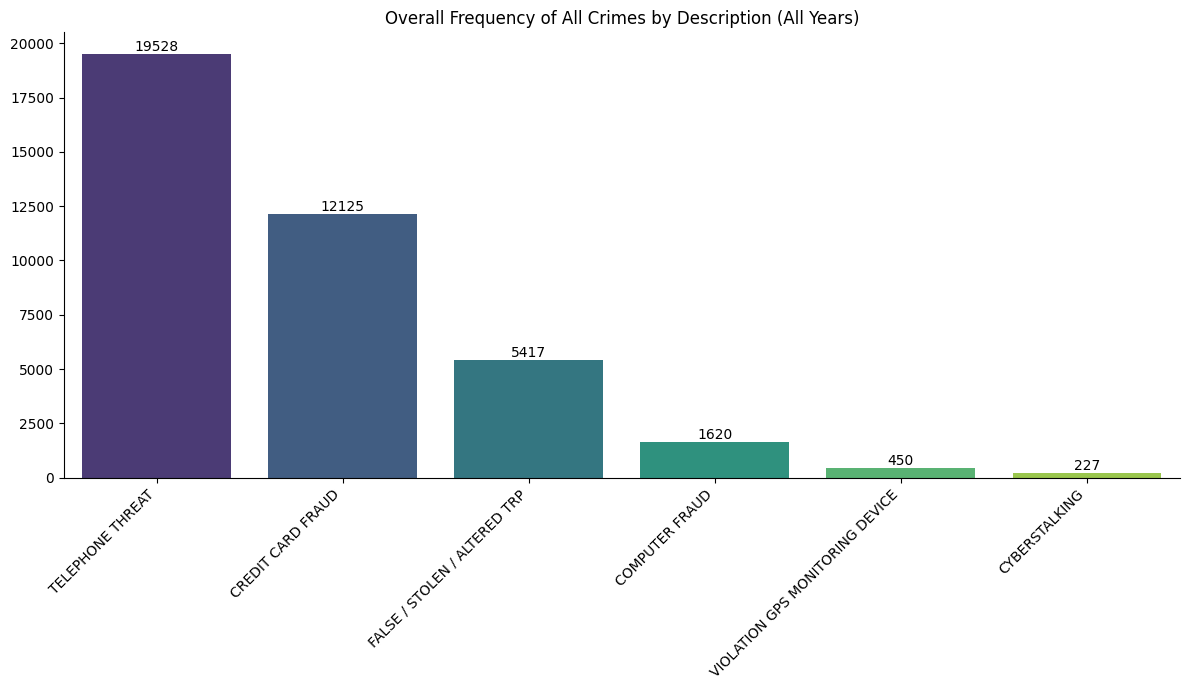

In [15]:
overall_crime_counts = df_clean.groupby('Description').size().reset_index(name='count')

# Sort the crime counts from biggest to smallest
overall_crime_counts = overall_crime_counts.sort_values(by='count', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=overall_crime_counts, x='Description', y='count', palette='viridis')
plt.title('Overall Frequency of All Crimes by Description (All Years)')
plt.xlabel('')
plt.ylabel('') # Set Y-axis label to blank
plt.xticks(rotation=45, ha='right')

# Remove top and left spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.tight_layout()
plt.show()

##**YEARWISE CHART OF A PARTICULAR CRIME**

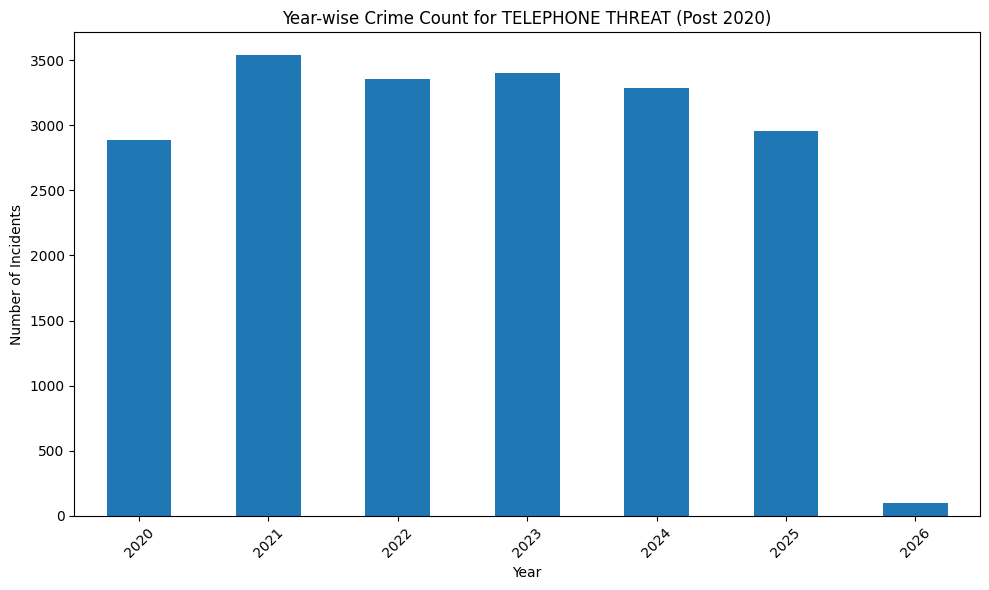

Year
2020    2888
2021    3536
2022    3357
2023    3401
2024    3289
2025    2954
2026     103
dtype: int64


In [16]:
year_counts = single_crime_df[single_crime_df['Year'] >= 2020].groupby('Year').size()
plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar', title=f"Year-wise Crime Count for {CRIME_DESCRIPTION} (Post 2020)")
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(year_counts)

##**MONTHWISE CHART FOR A PARTICULAR TIME**

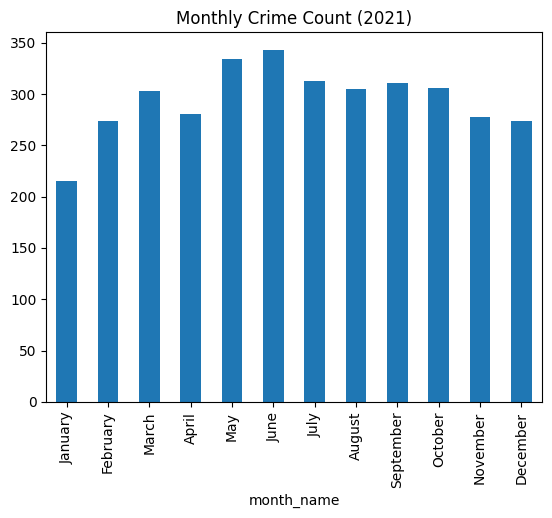

In [17]:
highest_year = year_counts.idxmax()
df_year = single_crime_df[single_crime_df['Year'] == highest_year]

month_counts = df_year.groupby('month_name').size().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

month_counts.plot(kind='bar', title=f"Monthly Crime Count ({highest_year})")
plt.show()

In [18]:
print(month_counts)
print(month_counts.idxmax())

month_name
January      215
February     274
March        303
April        280
May          334
June         343
July         313
August       305
September    311
October      306
November     278
December     274
dtype: int64
June


##**DAYWISE CHART FOR A PARTICULAR CRIME**

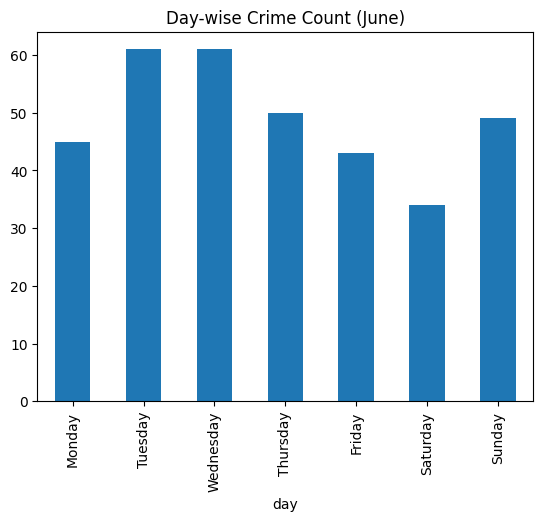

In [19]:
highest_month = month_counts.idxmax()
df_month = df_year[df_year['month_name'] == highest_month]

day_counts = df_month.groupby('day').size().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

day_counts.plot(kind='bar', title=f"Day-wise Crime Count ({highest_month})")
plt.show()

##**HOURWISE CHART OF A PARTICULAR CRIME**

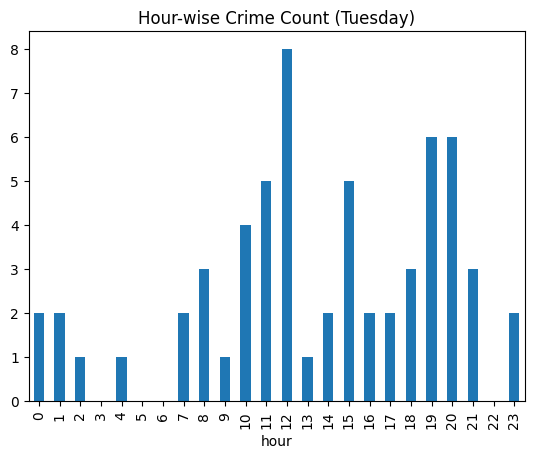

In [20]:
highest_day = day_counts.idxmax()
df_day = df_month[df_month['day'] == highest_day]

hour_counts = df_day.groupby('hour').size().reindex(range(24), fill_value=0)

hour_counts.plot(kind='bar', title=f"Hour-wise Crime Count ({highest_day})")
plt.show()

highest_hour = hour_counts.idxmax()
df_hour = df_day[df_day['hour'] == highest_hour]

###**MAP PLOTTED FOR HIGHEST HOUR AT HOURWISE CHART**

In [21]:
map_hour = folium.Map(location=[41.88, -87.63], zoom_start=12)
HeatMap(
    df_hour[['Latitude', 'Longitude']].dropna().values.tolist(),
    radius=10,
    blur=5
).add_to(map_hour)

map_hour

In [22]:
if not df_hour.empty:
    hotspots = df_hour.groupby(
        ['District', 'Ward', 'Location Description']
    ).size().reset_index(name='crime_count')

    hotspots = hotspots.sort_values(by='crime_count', ascending=False)
    display(hotspots.head(10))


,District,Ward,Location Description,crime_count
0,3,20.0,RESIDENCE,1
1,8,16.0,APARTMENT,1
2,11,27.0,APARTMENT,1
3,12,27.0,APARTMENT,1
4,16,31.0,SCHOOL - PUBLIC GROUNDS,1
5,17,33.0,APARTMENT,1
6,17,45.0,RESTAURANT,1
7,22,21.0,RESIDENCE,1
